### Loading Train and Test Data

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

feature_train = pd.read_csv('X_train_prepared.csv',  index_col=0)
target_train = pd.read_csv('y_train_prepared.csv', index_col=0).squeeze()
feature_test = pd.read_csv('X_test_processed.csv',  index_col=0)
target_test = pd.read_csv('y_test.csv', index_col=0).squeeze()

### Creating Polynomial Features

In [3]:

poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(feature_train)
X_test_poly  = poly.transform(feature_test)

print(f"Original features: {feature_train.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")

Original features: 18
Polynomial features: 189


### Creating and training the Model

In [4]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, target_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Prediction and Calculating MAE, RMSE and R²

In [5]:
y_pred_train_poly = poly_model.predict(X_train_poly)
y_pred_test_poly  = poly_model.predict(X_test_poly)

In [6]:
mae  = mean_absolute_error(target_test, y_pred_test_poly)
rmse = np.sqrt(mean_squared_error(target_test, y_pred_test_poly))
r2   = r2_score(target_test, y_pred_test_poly)
r2_train = r2_score(target_train, y_pred_train_poly)

print(f"\nPolynomial Linear Regression:")
print(f"MAE:          {mae:.4f}")
print(f"RMSE:         {rmse:.4f}")
print(f"R² on train:  {r2_train:.4f}")
print(f"R² on test:   {r2:.4f}")


Polynomial Linear Regression:
MAE:          20.2267
RMSE:         25.5333
R² on train:  0.9923
R² on test:   0.9922


Mae and rmse have very good values in our case. the r2 percentage is very high, close to perfectness.

### Plotting for Analysation

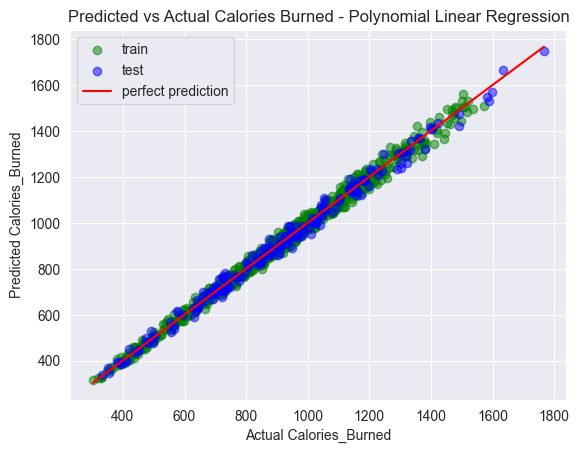

In [7]:
import matplotlib.pyplot as plt


plt.scatter(target_train, y_pred_train_poly, c='green', label='train', alpha=0.5)
plt.scatter(target_test,  y_pred_test_poly,  c='blue',  label='test',  alpha=0.5)

min_val = min(target_train.min(), target_test.min())
max_val = max(target_train.max(), target_test.max())
plt.plot([min_val, max_val], [min_val, max_val], c='red', label='perfect prediction')

plt.xlabel('Actual Calories_Burned')
plt.ylabel('Predicted Calories_Burned')
plt.legend()
plt.title('Predicted vs Actual Calories Burned - Polynomial Linear Regression')
plt.show()

even for high values our model has good predictions.

### Residual Distribution

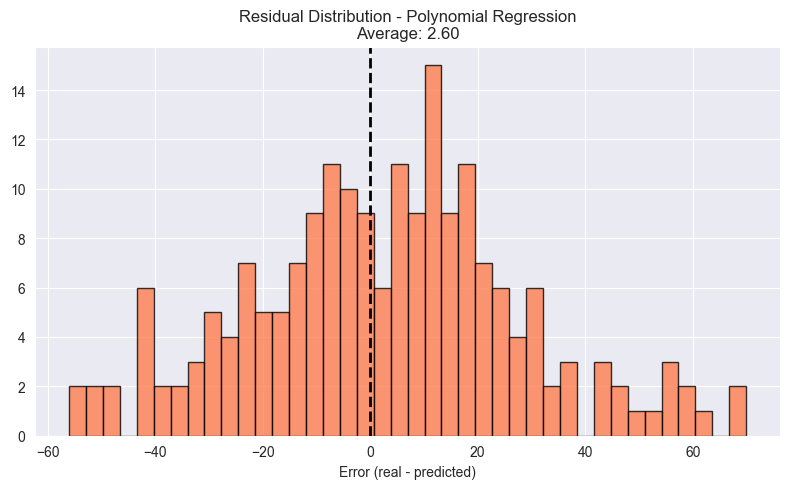

In [8]:
import matplotlib.pyplot as plt

residuals_poly = target_test.values - y_pred_test_poly

plt.figure(figsize=(8, 5))
plt.hist(residuals_poly, bins=40, color='coral', edgecolor='black', alpha=0.8)
plt.axvline(0, color='black', linestyle='--', lw=2)

plt.xlabel("Error (real - predicted)")
plt.title(f"Residual Distribution - Polynomial Regression\nAverage: {residuals_poly.mean():.2f}")
plt.tight_layout()
plt.show()

### Feature Importance 

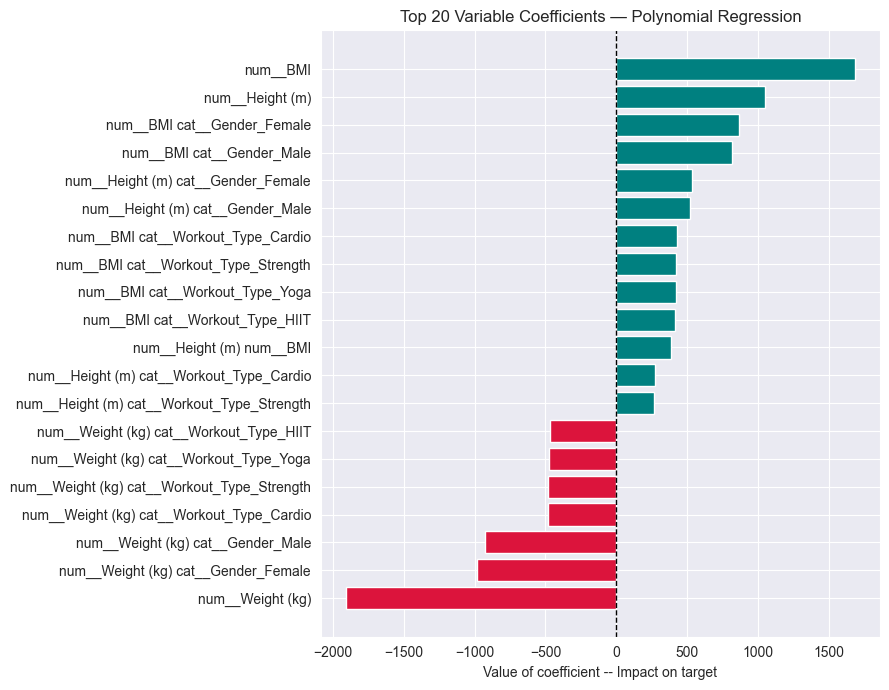

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


poly_feature_names = poly.get_feature_names_out(feature_train.columns)

importance_poly = poly_model.coef_


feat_df_poly = pd.DataFrame({
    'Feature': poly_feature_names,
    'Importance': importance_poly,
    'Abs_Importance': abs(importance_poly) 
})


top_20_features = feat_df_poly.sort_values('Abs_Importance', ascending=False).head(20)


top_20_features = top_20_features.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 7))


colors_poly = ['crimson' if x < 0 else 'teal' for x in top_20_features['Importance']]

plt.barh(top_20_features['Feature'], top_20_features['Importance'], color=colors_poly)

plt.title("Top 20 Variable Coefficients — Polynomial Regression")
plt.xlabel("Value of coefficient -- Impact on target")
plt.axvline(0, color='black', linestyle='--', lw=1) 
plt.tight_layout()
plt.show()

Like in the linear regression, the positive coefficient features push the final predicted number up and the negative down.

### Learning Curve

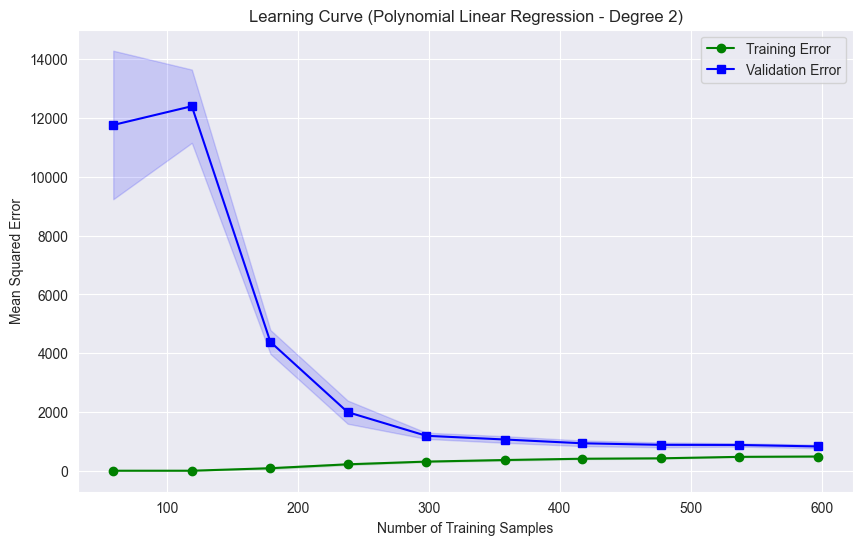

In [13]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Generate learning curve data using your existing model and training data
train_sizes, train_scores, test_scores = learning_curve(
    estimator=poly_model,
    X=X_train_poly,
    y=target_train,
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 points along the curve
    n_jobs=-1
)

# The scoring metric returns negative MSE, so we make it positive
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotting the learning curve
plt.figure(figsize=(10, 6))

# Training error
plt.plot(train_sizes, train_mean, label='Training Error', color='green', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='green', alpha=0.15)

# Validation error
plt.plot(train_sizes, test_mean, label='Validation Error', color='blue', marker='s')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='blue', alpha=0.15)

plt.title('Learning Curve (Polynomial Linear Regression - Degree 2)')
plt.xlabel('Number of Training Samples')
plt.ylabel('Mean Squared Error')
plt.legend(loc='best')
plt.grid(True)
plt.show()